In [3]:
!pip install kagglehub
!pip install scikit-learn
!pip install pandas
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# download dataset
import kagglehub
import os

path = kagglehub.dataset_download("mansoordaku/ckdisease")
csv_path = os.path.join(path, "kidney_disease.csv")
print("Downloaded to:", csv_path)

/home/pcuser/Code/JEE_MINI_PROJECT/ml-api/.venv/lib64/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: /home/pcuser/.cache/kagglehub/datasets/mansoordaku/ckdisease/versions/1/kidney_disease.csv


## Dataset Preprocess

In [5]:
# load dataset
import pandas as pd

df = pd.read_csv(csv_path)

In [6]:
# rename columns to make them more readabl
df = df.astype(str).apply(lambda x: x.str.strip())
df.replace(["?", "nan"], None, inplace=True)

rename_map = {
    'id': 'patient_id',
    'age': 'age',
    'bp': 'blood_pressure',
    'sg': 'urine_specific_gravity',
    'al': 'albumin',
    'su': 'sugar',
    'rbc': 'red_blood_cells_urine',
    'pc': 'pus_cells',
    'pcc': 'pus_cell_clumps',
    'ba': 'bacteria',
    'bgr': 'blood_glucose_random',
    'bu': 'blood_urea',
    'sc': 'serum_creatinine',
    'sod': 'sodium',
    'pot': 'potassium',
    'hemo': 'hemoglobin',
    'pcv': 'packed_cell_volume',
    'wc': 'white_blood_cell_count',
    'rc': 'red_blood_cell_count',
    'htn': 'hypertension',
    'dm': 'diabetes_mellitus',
    'cad': 'coronary_artery_disease',
    'appet': 'appetite',
    'pe': 'pedal_edema',
    'ane': 'anemia',
    'classification': 'ckd_diagnosis'
}

df.rename(columns=rename_map, inplace=True)
df.head()

,patient_id,age,blood_pressure,urine_specific_gravity,albumin,sugar,red_blood_cells_urine,pus_cells,pus_cell_clumps,bacteria,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,ckd_diagnosis
0,0,48.0,80.0,1.02,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.01,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [7]:
#list columns unique values
for i in df.columns:
    print(f"Number of unique values: {len(df[i].unique())}")
    print(f"{i}:  {df[i].value_counts()}")
    print("-" * 40)

Number of unique values: 400
patient_id:  patient_id
0      1
1      1
2      1
3      1
4      1
      ..
395    1
396    1
397    1
398    1
399    1
Name: count, Length: 400, dtype: int64
----------------------------------------
Number of unique values: 77
age:  age
60.0    19
65.0    17
48.0    12
50.0    12
55.0    12
        ..
90.0     1
78.0     1
2.0      1
22.0     1
79.0     1
Name: count, Length: 76, dtype: int64
----------------------------------------
Number of unique values: 11
blood_pressure:  blood_pressure
80.0     116
70.0     112
60.0      71
90.0      53
100.0     25
50.0       5
110.0      3
140.0      1
180.0      1
120.0      1
Name: count, dtype: int64
----------------------------------------
Number of unique values: 6
urine_specific_gravity:  urine_specific_gravity
1.02     106
1.01      84
1.025     81
1.015     75
1.005      7
Name: count, dtype: int64
----------------------------------------
Number of unique values: 7
albumin:  albumin
0.0    199
1.0     44

In [8]:
# defining the value type of each column (numerical, ordinal, nominal)
column_data_types = {
    'age': 'numerical',
    'blood_pressure': 'numerical',
    'urine_specific_gravity': 'numerical',
    'albumin': 'ordinal',
    'sugar': 'ordinal',
    'red_blood_cells_urine': 'nominal',
    'pus_cells': 'nominal',
    'pus_cell_clumps': 'nominal',
    'bacteria': 'nominal',
    'blood_glucose_random': 'numerical',
    'blood_urea': 'numerical',
    'serum_creatinine': 'numerical',
    'sodium': 'numerical',
    'potassium': 'numerical',
    'hemoglobin': 'numerical',
    'packed_cell_volume': 'numerical',
    'white_blood_cell_count': 'numerical',
    'red_blood_cell_count': 'numerical',
    'hypertension': 'nominal',
    'diabetes_mellitus': 'nominal',
    'coronary_artery_disease': 'nominal',
    'appetite': 'nominal',
    'pedal_edema': 'nominal',
    'anemia': 'nominal',
    'ckd_diagnosis': 'nominal'
}


In [9]:
# encoding dataset, using on-hot on nominal variables
# for ordinal and numerical ones we just replace missing values with the median

for col in df.columns:
  if(col == "patient_id" or col not in column_data_types):
    continue
  if(col == "ckd_diagnosis"):
    df[col] = df[col].str.strip()
    df[col] = df[col].map({'ckd': 1, 'notckd': 0})
    continue
  if(column_data_types[col] == "nominal"):
    df[col] = df[col].str.strip()
    df[col] = df[col].fillna("missing")
    unique_categories = df[col].unique()
    for category in unique_categories:
      new_col = f"{col}_{category}"
      df[new_col] = df[col].apply(lambda x: 1 if str(x) == str(category) else 0)
    df = df.drop(col, axis=1)
  else:
    df[col] = pd.to_numeric(df[col])
    df[col] = df[col].fillna(df[col].median())


df.head()

df.to_csv("../dataset/preprocessed_kidney_disease_data.csv", index=False)

## Models Training

In [10]:
#Spliting dataset, into training set and testing set
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split

#disable the annoying warning, I don't know what it means but the model works.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

X = df.drop(columns=['patient_id', 'ckd_diagnosis'])
y = df['ckd_diagnosis']

#change test_size later, current value is just for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

models = {}

In [11]:
# standrise the scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
#Training model using logistic regression
from sklearn.linear_model import LogisticRegression

logistic_regression_model = LogisticRegression(max_iter=5000)
logistic_regression_model.fit(X_train, y_train)
models["Logistic Regression"] = logistic_regression_model

In [13]:
#Training model using Support Vector Machine
from sklearn.svm import SVC

svc_model = SVC()
svc_model.fit(X_train, y_train)
models["Support Vector Machine (SVM)"] = svc_model

In [14]:
#Training model using Decision Trees
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X_train, y_train)
models["Decision Trees"] = decision_tree_model

In [15]:
#Training model using Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)
models["Random Forest"] = random_forest_model

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
models["K-Nearest Neighbors (KNN)"] = knn_model

In [17]:
#Models Evaluation
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

metric_results = {
  "Accuracy": [],
  "F1-score": [],
  "Precision": [],
  "Recall": [],
  "Cross Value Score": []
}
for model in models:
  y_pred = models[model].predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  cv_model = make_pipeline(StandardScaler(), models[model])
  cv_score = cross_val_score(cv_model, X, y, cv=5, scoring='f1').mean()

  metric_results["Accuracy"].append(accuracy)
  metric_results["F1-score"].append(f1)
  metric_results["Precision"].append(precision)
  metric_results["Recall"].append(recall)
  metric_results["Cross Value Score"].append(cv_score)
  
  print("=" * 10, model, "=" * 10)
  print(f"Accuracy: {accuracy}")
  print(f"F1-score: {f1}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"Cross Value Score: {cv_score}\n") 


========== Logistic Regression ==========
Accuracy: 1.0
F1-score: 1.0
Precision: 1.0
Recall: 1.0
Cross Value Score: 1.0

========== Support Vector Machine (SVM) ==========
Accuracy: 0.9875
F1-score: 0.9904761904761905
Precision: 0.9811320754716981
Recall: 1.0
Cross Value Score: 0.998019801980198

========== Decision Trees ==========
Accuracy: 0.9875
F1-score: 0.9902912621359223
Precision: 1.0
Recall: 0.9807692307692307
Cross Value Score: 0.9742162686856922

========== Random Forest ==========
Accuracy: 1.0
F1-score: 1.0
Precision: 1.0
Recall: 1.0
Cross Value Score: 0.998019801980198

========== K-Nearest Neighbors (KNN) ==========
Accuracy: 0.9875
F1-score: 0.9902912621359223
Precision: 1.0
Recall: 0.9807692307692307
Cross Value Score: 0.9794217687074831



##### Scores were too good, so we used Cross Validation to make sure the model wasn't overfitting. CV scores stayed high, which signify that the models are most likely working well.

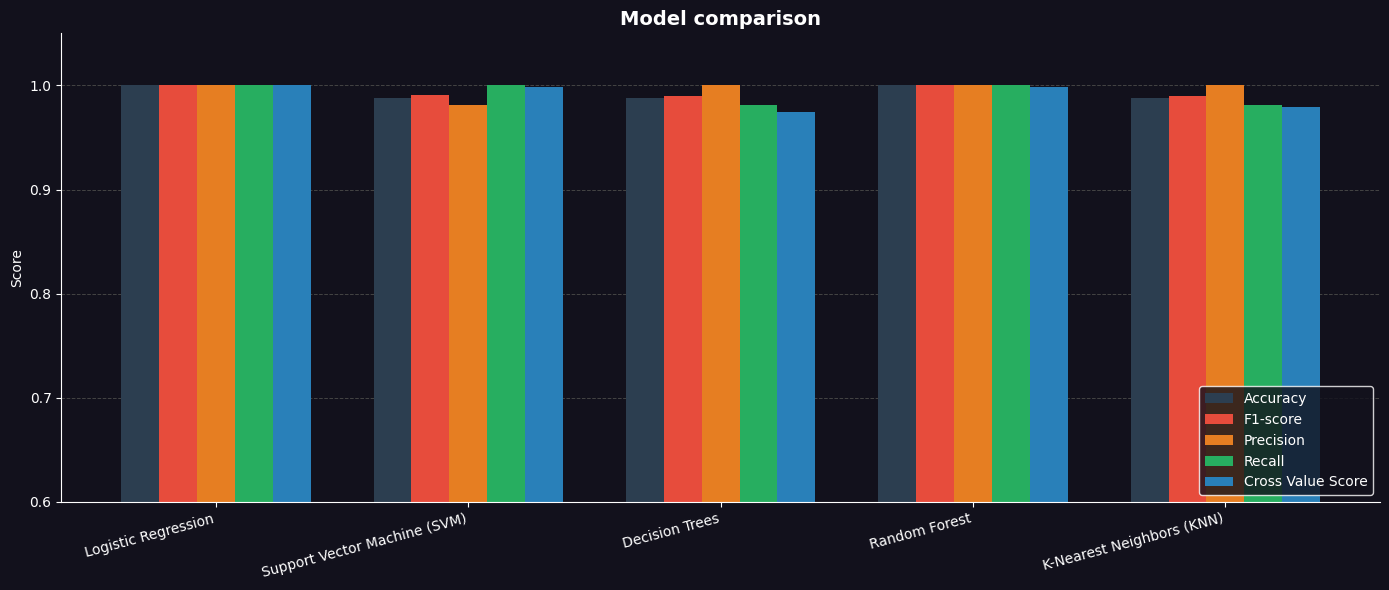

In [18]:
import matplotlib.pyplot as plt
import numpy as np

models_names = list(models.keys())
colors = ['#2C3E50', '#E74C3C', '#E67E22', '#27AE60', '#2980B9']

x = np.arange(len(models_names))
width = 0.15
fig, ax = plt.subplots(figsize=(14, 6))

ax.set_facecolor('#12111c')
fig.patch.set_facecolor('#12111c')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

ax.yaxis.grid(True, color='#444444', linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

for i, (metric, values) in enumerate(metric_results.items()):
    ax.bar(x + i * width, values, width, label=metric, color=colors[i])

ax.set_xticks(x + width * 2)

ax.set_xticklabels(models_names, rotation=15, ha='right', color='white')
ax.tick_params(colors='white')

ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Score', color='white')
ax.set_title('Model comparison', color='white', fontsize=14, fontweight='bold')

legend = ax.legend(loc='lower right', facecolor='#12111c', edgecolor='white')
plt.setp(legend.get_texts(), color='white') 

plt.tight_layout()
plt.show()

In [20]:
#Save Models
import pickle

for model in models:
    module_path = os.path.join('../module/', model.lower().replace(" ", "_")+'.pkl')
    with open(module_path, 'wb') as f:
        pickle.dump(models[model], f)

In [ ]:
#Predict